# Fairness in Diabetes-Related Classification Across Racial/Ethnic Groups Using IPUMS Health Survey Data

This notebook presents the experimental pipeline for our course project on fairness in healthcare machine learning. Using IPUMS/NHIS survey data, we construct a diabetes-related classification task and evaluate whether predictive models perform differently across racial/ethnic groups.

The notebook includes data cleaning, target and protected-group construction, feature preprocessing, baseline model training, overall performance evaluation, subgroup fairness analysis, and visualization of disparities across groups.

## Note on Project Scope Refinement

Our initial project proposal framed the task as predicting Type 2 diabetes and examining whether genetic factors directly explain ethnic disparities. However, after reviewing the available IPUMS/NHIS survey variables and implementing the first round of experiments, I concluded that the scope of the project is better framed as **fairness in diabetes-related classification across racial/ethnic groups**.

This refinement is motivated by the structure of the dataset itself. The IPUMS/NHIS data used here are survey-based health data rather than genetic or causal data. The available variables primarily describe demographic characteristics, race/ethnicity, education, healthcare access, affordability barriers, and diabetes-related health status. These variables support a supervised classification task and subgroup-based fairness evaluation, but they do not support direct inference about genetic mechanisms or causal pathways explaining disparity.

At the same time, the dataset is well suited for fairness-oriented analysis. It contains:
- diabetes-related variables that can be used to define a classification target,
- race/ethnicity-related variables that can be used to define protected groups,
- social and healthcare-access variables that may contribute to predictive disparities, and
- a large multi-year survey sample that enables comparison across demographic groups.

For these reasons, this notebook focuses on whether machine learning models exhibit differences in predictive performance and error rates across racial/ethnic groups, rather than attempting to identify direct genetic explanations for those disparities.

Specifically, this notebook:
- constructs a diabetes-related classification task from survey variables,
- uses race/ethnicity-related variables as protected group indicators,
- compares baseline predictive models, and
- evaluates fairness using group-based performance metrics such as recall, false positive rate, false negative rate, and predicted positive rate.

This reframed scope better matches the data, methods, and fairness objectives of the course project.

In [43]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

from IPython.display import display
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

## Dataset Overview

This project uses a sample extracted from IPUMS Health Surveys / NHIS data. The dataset contains demographic, education, healthcare access, and diabetes-related variables collected across multiple survey years.

At this stage, the goal is to load the data, inspect its structure, and identify the variables that may be used for:
- the classification target,
- protected group definitions, and
- candidate predictive features.

### Data Loading

In [44]:
project_dir = Path(".")
data_path = project_dir / "ipums_sample.csv"

df = pd.read_csv(data_path)

print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

print("Survey years in sample:", sorted(df["YEAR"].dropna().unique().tolist()))
df

Shape: (188419, 30)

Columns:
['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'PERNUM', 'NHISPID', 'HHX', 'SAMPWEIGHT', 'LONGWEIGHT', 'PARTWEIGHT', 'ASTATFLG', 'CSTATFLG', 'RACENEW', 'HISPETH', 'USBORN', 'CITIZEN', 'EDUC', 'MAXEDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY', 'DIABTYPE', 'INSULIN', 'DIAPILLS', 'DIAGLP', 'DIAYRSAGO', 'DIAPRE']
Survey years in sample: [2020, 2021, 2022, 2023, 2024]


,YEAR,SERIAL,STRATA,PSU,NHISHID,PERNUM,NHISPID,HHX,SAMPWEIGHT,LONGWEIGHT,...,USUALPL,YSKIMPMEDYR,YSKIPMEDYR,HIUNABLEPAY,DIABTYPE,INSULIN,DIAPILLS,DIAGLP,DIAYRSAGO,DIAPRE
0,2020,1,150,25,0002020H000002,1,0002020H00000210,H000002,5946.002,17605.50,...,2,1,1,0,0,0,0,NaN,96,1
1,2020,2,111,10,0002020H000003,1,0002020H00000310,H000003,6288.726,0.00,...,3,1,1,0,0,0,0,NaN,96,1
2,2020,3,133,3,0002020H000004,1,0002020H00000410,H000004,6083.271,0.00,...,2,1,1,0,0,0,0,NaN,96,1
3,2020,4,139,45,0002020H000007,1,0002020H00000710,H000007,11306.962,0.00,...,2,1,1,0,3,1,2,NaN,3,2
4,2020,5,130,21,0002020H000009,1,0002020H00000910,H000009,6471.818,19317.18,...,2,1,1,0,0,1,1,NaN,96,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188414,2024,33913,135,25,0002024H080023,1,0002024H08002310,H080023,9778.000,NaN,...,2,1,1,0,0,1,1,1.0,96,2
188415,2024,33914,116,19,0002024H080026,1,0002024H08002610,H080026,28585.000,NaN,...,2,1,1,0,0,0,0,0.0,96,1
188416,2024,33915,119,6,0002024H080027,1,0002024H08002710,H080027,10140.000,NaN,...,2,1,1,0,0,0,0,0.0,96,1
188417,2024,33916,107,36,0002024H080034,1,0002024H08003410,H080034,8316.000,NaN,...,3,1,1,0,0,0,0,0.0,96,1


### Data Inspection

In [45]:
selected_features = [
    "YEAR", "USBORN", "CITIZEN", "EDUC", "MAXEDUC",
    "SCHOOLNOW", "USUALPL", "YSKIMPMEDYR",
    "YSKIPMEDYR", "HIUNABLEPAY"
]

protected_group_candidates = ["RACENEW", "HISPETH"]
diabetes_variables = ["DIABTYPE", "INSULIN", "DIAPILLS", "DIAGLP", "DIAYRSAGO", "DIAPRE"]

missing_cols = [col for col in selected_features + protected_group_candidates + diabetes_variables if col not in df.columns]
print("Missing columns from analysis-related variables:", missing_cols)

print("\nDataFrame info:")
df.info()

missing_summary = (
    df[selected_features + protected_group_candidates + diabetes_variables]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in analysis-related variables:")
print(missing_summary)

Missing columns from analysis-related variables: []

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 188419 entries, 0 to 188418
Data columns (total 30 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   YEAR         188419 non-null  int64  
 1   SERIAL       188419 non-null  int64  
 2   STRATA       188419 non-null  int64  
 3   PSU          188419 non-null  int64  
 4   NHISHID      188419 non-null  str    
 5   PERNUM       188419 non-null  int64  
 6   NHISPID      188419 non-null  str    
 7   HHX          188419 non-null  str    
 8   SAMPWEIGHT   188419 non-null  float64
 9   LONGWEIGHT   37358 non-null   float64
 10  PARTWEIGHT   37358 non-null   float64
 11  ASTATFLG     188419 non-null  int64  
 12  CSTATFLG     188419 non-null  int64  
 13  RACENEW      188419 non-null  int64  
 14  HISPETH      188419 non-null  int64  
 15  USBORN       188419 non-null  int64  
 16  CITIZEN      188419 non-null  int64  
 17  EDUC     

In [46]:
for col in ["DIABTYPE", "RACENEW"]:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False).sort_index())
    
    print(f"\nUnique values in {col}:")
    print(sorted(df[col].dropna().unique()))


DIABTYPE value counts:
DIABTYPE
0    171980
1      1374
2     13833
3       360
7        13
9       859
Name: count, dtype: int64

Unique values in DIABTYPE:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(7), np.int64(9)]

RACENEW value counts:
RACENEW
100    137614
200     20644
300      1773
400     11469
510      4194
542      1865
997       111
998     10587
999       162
Name: count, dtype: int64

Unique values in RACENEW:
[np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(510), np.int64(542), np.int64(997), np.int64(998), np.int64(999)]


In [47]:
special_codes = {
    7, 8, 9,
    97, 98, 99,
    997, 998, 999,
    9997, 9998, 9999
}

feature_quality_summary = pd.DataFrame({
    "feature": selected_features,
    "missing_count": [df[col].isna().sum() for col in selected_features],
    "missing_rate": [round(df[col].isna().mean(), 4) for col in selected_features],
    "special_code_count": [int(df[col].isin(special_codes).sum()) for col in selected_features],
    "special_code_rate": [round(float(df[col].isin(special_codes).mean()), 4) for col in selected_features],
    "n_unique": [df[col].nunique(dropna=False) for col in selected_features]
}).sort_values(by="special_code_rate", ascending=False)

feature_quality_summary

,feature,missing_count,missing_rate,special_code_count,special_code_rate,n_unique
4,MAXEDUC,0,0.0,97113,0.5154,13
2,CITIZEN,0,0.0,6010,0.0319,5
1,USBORN,0,0.0,5753,0.0305,5
5,SCHOOLNOW,0,0.0,5620,0.0298,6
6,USUALPL,0,0.0,1176,0.0062,6
3,EDUC,0,0.0,741,0.0039,16
9,HIUNABLEPAY,0,0.0,435,0.0023,6
7,YSKIMPMEDYR,0,0.0,39,0.0002,6
8,YSKIPMEDYR,0,0.0,36,0.0002,6
0,YEAR,0,0.0,0,0.0000,5


In [48]:
high_risk_features = ["MAXEDUC", "CITIZEN", "USBORN", "SCHOOLNOW", "USUALPL", "EDUC"]

for col in high_risk_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())


--- MAXEDUC ---
MAXEDUC
1      7586
2      2198
3      2898
4     32494
5     26075
6      8059
7     18358
8     48859
9     29896
20     9263
21      965
22     1356
96      412
Name: count, dtype: int64

--- CITIZEN ---
CITIZEN
1     10373
2    172036
7       302
8      5637
9        71
Name: count, dtype: int64

--- USBORN ---
USBORN
10     25189
20    157477
97       123
98      5614
99        16
Name: count, dtype: int64

--- SCHOOLNOW ---
SCHOOLNOW
0     37567
1    136759
2      8473
7        51
8      5560
9         9
Name: count, dtype: int64

--- USUALPL ---
USUALPL
1     13928
2    170068
3      3247
7        58
8      1026
9        92
Name: count, dtype: int64

--- EDUC ---
EDUC
0      37567
102       59
103    10092
116     2403
201    34203
202     3439
301    22573
302     5904
303    13711
400    34955
510    16944
520     4592
521      518
522      718
997      225
999      516
Name: count, dtype: int64


In [49]:
output_dir = Path("outputs_2")
output_dir.mkdir(exist_ok=True)

df["DIABTYPE"].value_counts(dropna=False).sort_index().reset_index().rename(
    columns={"index": "DIABTYPE_value", "DIABTYPE": "count"}
).to_csv(output_dir / "diabtype_value_counts.csv", index=False)

df["RACENEW"].value_counts(dropna=False).sort_index().reset_index().rename(
    columns={"index": "RACENEW_value", "RACENEW": "count"}
).to_csv(output_dir / "racenew_value_counts.csv", index=False)

feature_quality_summary.to_csv(output_dir / "feature_quality_summary.csv", index=False)

print("Saved summary files.")

Saved summary files.


### Target Definition Audit

The final task in this notebook is framed as **diabetes-related binary classification** rather than a direct model of Type 2 diabetes genetics or causality. The target is constructed from `DIAPRE`, and the protected groups are based on `RACENEW` after regrouping into major racial/ethnic categories used in the analysis. This framing is consistent with the available survey variables and with the fairness-focused scope of the project.

In [50]:
target_audit_cols = ["DIAPRE", "DIABTYPE", "DIAGLP", "DIAYRSAGO"]

for col in target_audit_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False).sort_index())

print("\nNon-null rate for DIAGLP:")
print(round(df["DIAGLP"].notna().mean(), 4))

target_definition_summary = pd.DataFrame({
    "variable": target_audit_cols,
    "non_null_count": [df[c].notna().sum() for c in target_audit_cols],
    "non_null_rate": [round(df[c].notna().mean(), 4) for c in target_audit_cols],
    "n_unique": [df[c].nunique(dropna=False) for c in target_audit_cols]
})

display(target_definition_summary)


=== DIAPRE ===
DIAPRE
1    162570
2     25563
7       126
9       160
Name: count, dtype: int64

=== DIABTYPE ===
DIABTYPE
0    171980
1      1374
2     13833
3       360
7        13
9       859
Name: count, dtype: int64

=== DIAGLP ===
DIAGLP
0.0     33659
1.0      6159
2.0      1163
7.0         1
9.0         7
NaN    147430
Name: count, dtype: int64

=== DIAYRSAGO ===
DIAYRSAGO
0        483
1        803
2        854
3        721
4        637
       ...  
86        14
87        48
96    171983
97        11
99       584
Name: count, Length: 90, dtype: int64

Non-null rate for DIAGLP:
0.2175


,variable,non_null_count,non_null_rate,n_unique
0,DIAPRE,188419,1.0000,4
1,DIABTYPE,188419,1.0000,6
2,DIAGLP,40989,0.2175,6
3,DIAYRSAGO,188419,1.0000,90


We inspected several diabetes-related variables (DIAPRE, DIABTYPE, DIAGLP, and DIAYRSAGO) to determine which variable was most suitable for defining the prediction target. DIAPRE provided complete coverage of the sample and required relatively limited cleaning, whereas DIAGLP was missing for most observations and DIAYRSAGO contained many non-substantive codes. Based on this audit, we used DIAPRE to construct a binary diabetes-related label for the current version of the analysis.

## Data Cleaning

In [51]:
df_model = df.copy()

# Construct binary target from DIABTYPE
df_model = df_model[df_model["DIABTYPE"].isin([0, 1, 2, 3])].copy()
df_model["diabetes_label"] = df_model["DIABTYPE"].map({0: 0,
                                                       1: 0, 
                                                       2: 1,
                                                       3: 0})

# Retain main race categories for baseline subgroup analysis
valid_race_codes = [100, 200, 300, 400, 510, 542]
df_model = df_model[df_model["RACENEW"].isin(valid_race_codes)].copy()

race_map = {
    100: "White",
    200: "Black",
    300: "AIAN",
    400: "Asian",
    510: "Other/Multi",
    542: "Other/Multi"
}
df_model["race_group"] = df_model["RACENEW"].map(race_map)

model_features = [
    "YEAR", "USBORN", "CITIZEN", "EDUC",
    "SCHOOLNOW", "USUALPL", "YSKIMPMEDYR",
    "YSKIPMEDYR", "HIUNABLEPAY"
]

target_col = "diabetes_label"
protected_col = "RACENEW"

print("Shape after target/protected-group cleaning:", df_model.shape)

print("\nBinary target distribution:")
print(df_model[target_col].value_counts().sort_index())

print("\nProtected-group distribution (RACENEW codes):")
print(df_model[protected_col].value_counts().sort_index())

print("\nReadable race-group distribution:")
print(df_model["race_group"].value_counts())

Shape after target/protected-group cleaning: (176773, 32)

Binary target distribution:
diabetes_label
0    163636
1     13137
Name: count, dtype: int64

Protected-group distribution (RACENEW codes):
RACENEW
100    137093
200     20490
300      1756
400     11400
510      4183
542      1851
Name: count, dtype: int64

Readable race-group distribution:
race_group
White          137093
Black           20490
Asian           11400
Other/Multi      6034
AIAN             1756
Name: count, dtype: int64


In [52]:
model_features = [
    "YEAR", "USBORN", "CITIZEN", "EDUC",
    "SCHOOLNOW", "USUALPL", "YSKIMPMEDYR",
    "YSKIPMEDYR", "HIUNABLEPAY"
]

special_codes = [7, 8, 9, 97, 98, 99, 997, 998, 999, 9997, 9998, 9999]

for col in model_features:
    if col != "YEAR":
        df_model[col] = df_model[col].replace(special_codes, np.nan)

clean_missing_summary = pd.DataFrame({
    "missing_count_after_recoding": df_model[model_features].isna().sum(),
    "missing_rate_after_recoding": df_model[model_features].isna().mean().round(4)
}).sort_values(by="missing_rate_after_recoding", ascending=False)

print("Missingness after recoding non-substantive feature values:")
display(clean_missing_summary)

required_cols = ["diabetes_label", "race_group"] + model_features
df_complete = df_model[required_cols].dropna().copy()

print("\nShape before dropping missing:", df_model[required_cols].shape)
print("Shape after dropping missing:", df_complete.shape)
print("Rows removed:", df_model[required_cols].shape[0] - df_complete.shape[0])
print("Retention rate:", round(df_complete.shape[0] / df_model[required_cols].shape[0], 4))

Missingness after recoding non-substantive feature values:


,missing_count_after_recoding,missing_rate_after_recoding
CITIZEN,5417,0.0306
USBORN,5243,0.0297
SCHOOLNOW,5138,0.0291
USUALPL,1089,0.0062
EDUC,631,0.0036
HIUNABLEPAY,393,0.0022
YSKIMPMEDYR,33,0.0002
YSKIPMEDYR,31,0.0002
YEAR,0,0.0000



Shape before dropping missing: (176773, 11)
Shape after dropping missing: (170028, 11)
Rows removed: 6745
Retention rate: 0.9618


In [53]:
n_initial = len(df)
n_after_target = len(df[df["DIABTYPE"].isin([0, 1, 2, 3])].copy())

valid_race_codes = [100, 200, 300, 400, 510, 542]
tmp_after_race = df.copy()
n_after_race = len(tmp_after_race[tmp_after_race["RACENEW"].isin(valid_race_codes)].copy())
n_final_complete = len(df_complete)

cleaning_pipeline_summary = pd.DataFrame({
    "step": [
        "Initial raw sample",
        "Keep DIABTYPE in {0,1,2,3}",
        "Keep valid RACENEW codes",
        "Drop rows with missing model features"
    ],
    "n_remaining": [n_initial, n_after_target, n_after_race, n_final_complete]
})
cleaning_pipeline_summary["pct_of_initial"] = (
    cleaning_pipeline_summary["n_remaining"] / n_initial
).round(4)

display(cleaning_pipeline_summary)
cleaning_pipeline_summary.to_csv(output_dir / "cleaning_pipeline_summary.csv", index=False)
print("Saved: outputs/cleaning_pipeline_summary.csv")

,step,n_remaining,pct_of_initial
0,Initial raw sample,188419,1.0000
1,"Keep DIABTYPE in {0,1,2,3}",187547,0.9954
2,Keep valid RACENEW codes,177559,0.9424
3,Drop rows with missing model features,170028,0.9024


Saved: outputs/cleaning_pipeline_summary.csv


In [54]:
print("Final modeling dataset shape:", df_complete.shape)

print("\nLabel distribution:")
print(df_complete["diabetes_label"].value_counts().sort_index())
print(df_complete["diabetes_label"].value_counts(normalize=True).sort_index().round(4))

print("\nRace-group distribution:")
print(df_complete["race_group"].value_counts())
print(df_complete["race_group"].value_counts(normalize=True).round(4))

output_dir = Path("outputs_2")
output_dir.mkdir(exist_ok=True)

df_complete.to_csv(output_dir / "ipums_modeling_dataset_v1.csv", index=False)

print("\nSaved: outputs/ipums_modeling_dataset_v1.csv")

Final modeling dataset shape: (170028, 11)

Label distribution:
diabetes_label
0    157440
1     12588
Name: count, dtype: int64
diabetes_label
0    0.926
1    0.074
Name: proportion, dtype: float64

Race-group distribution:
race_group
White          132547
Black           19149
Asian           10818
Other/Multi      5835
AIAN             1679
Name: count, dtype: int64
race_group
White          0.7796
Black          0.1126
Asian          0.0636
Other/Multi    0.0343
AIAN           0.0099
Name: proportion, dtype: float64

Saved: outputs/ipums_modeling_dataset_v1.csv


## Train/Test Split and Feature Encoding

In [55]:
target_col = "diabetes_label"
protected_col = "race_group"

X = df_complete[model_features].copy()
y = df_complete[target_col].copy()
protected_group = df_complete[protected_col].copy()

X_train, X_test, y_train, y_test, protected_train, protected_test = train_test_split(
    X, y, protected_group,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

print("\nTrain protected-group distribution:")
print(protected_train.value_counts(normalize=True).round(4))

print("\nTest protected-group distribution:")
print(protected_test.value_counts(normalize=True).round(4))

X_train shape: (136022, 9)
X_test shape: (34006, 9)

Train label distribution:
diabetes_label
0    0.926
1    0.074
Name: proportion, dtype: float64

Test label distribution:
diabetes_label
0    0.926
1    0.074
Name: proportion, dtype: float64

Train protected-group distribution:
race_group
White          0.7789
Black          0.1136
Asian          0.0634
Other/Multi    0.0342
AIAN           0.0099
Name: proportion, dtype: float64

Test protected-group distribution:
race_group
White          0.7821
Black          0.1088
Asian          0.0644
Other/Multi    0.0348
AIAN           0.0098
Name: proportion, dtype: float64


### Subgroup Sample Sizes

Because subgroup fairness estimates can be unstable for small groups, we summarize train/test sample sizes and positive-label counts by race group below. In particular, the AIAN subgroup is much smaller than the White subgroup and should be interpreted with additional caution in the report.

In [56]:
train_group_summary = pd.DataFrame({
    "race_group": protected_train.groupby(protected_train).size().index,
    "n_train": protected_train.groupby(protected_train).size().values
})

test_group_summary = pd.DataFrame({
    "race_group": protected_test.groupby(protected_test).size().index,
    "n_test": protected_test.groupby(protected_test).size().values
})

train_pos_summary = pd.DataFrame({
    "race_group": protected_train.values,
    "y_train": y_train.values
}).groupby("race_group").agg(
    n_train_positive=("y_train", "sum"),
    train_positive_rate=("y_train", "mean")
).reset_index()

test_pos_summary = pd.DataFrame({
    "race_group": protected_test.values,
    "y_test": y_test.values
}).groupby("race_group").agg(
    n_test_positive=("y_test", "sum"),
    test_positive_rate=("y_test", "mean")
).reset_index()

subgroup_sample_summary = (
    train_group_summary
    .merge(test_group_summary, on="race_group", how="outer")
    .merge(train_pos_summary, on="race_group", how="outer")
    .merge(test_pos_summary, on="race_group", how="outer")
    .sort_values("race_group")
    .reset_index(drop=True)
)

display(subgroup_sample_summary.round(4))
subgroup_sample_summary.to_csv(output_dir / "subgroup_sample_summary.csv", index=False)
print("Saved: outputs/subgroup_sample_summary.csv")

,race_group,n_train,n_test,n_train_positive,train_positive_rate,n_test_positive,test_positive_rate
0,AIAN,1345,334,146,0.1086,32,0.0958
1,Asian,8628,2190,523,0.0606,118,0.0539
2,Black,15449,3700,1615,0.1045,377,0.1019
3,Other/Multi,4650,1185,228,0.0490,45,0.0380
4,White,105950,26597,7558,0.0713,1946,0.0732


Saved: outputs/subgroup_sample_summary.csv


In [57]:
categorical_features = model_features

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor for categorical feature encoding is ready.")
print("Categorical features:", categorical_features)

Preprocessor for categorical feature encoding is ready.
Categorical features: ['YEAR', 'USBORN', 'CITIZEN', 'EDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY']


## Baseline Logistic Regression

In [58]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

print("Baseline logistic regression pipeline fitted successfully.")
print("Features used:", categorical_features)

Baseline logistic regression pipeline fitted successfully.
Features used: ['YEAR', 'USBORN', 'CITIZEN', 'EDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY']


In [59]:
y_pred = log_reg_pipeline.predict(X_test)
y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

overall_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob)
}

print("Overall metrics:")
for k, v in overall_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Overall metrics:
accuracy: 0.5294
balanced_accuracy: 0.7225
precision: 0.1309
recall: 0.9492
f1: 0.2300
roc_auc: 0.7805

Confusion matrix:
[[15614 15874]
 [  128  2390]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.50      0.66     31488
           1       0.13      0.95      0.23      2518

    accuracy                           0.53     34006
   macro avg       0.56      0.72      0.45     34006
weighted avg       0.93      0.53      0.63     34006



In [60]:
test_results = X_test.copy()
test_results["y_true"] = y_test.values
test_results["y_pred"] = y_pred
test_results["y_prob"] = y_prob
test_results["race_group"] = protected_test.values

group_results = []

for grp in sorted(test_results["race_group"].unique()):
    subset = test_results[test_results["race_group"] == grp].copy()
    
    tn, fp, fn, tp = confusion_matrix(
        subset["y_true"], subset["y_pred"], labels=[0, 1]
    ).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    
    group_results.append({
        "race_group": grp,
        "n_samples": len(subset),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "positive_rate_true": subset["y_true"].mean(),
        "predicted_positive_rate": subset["y_pred"].mean(),
        "accuracy": accuracy_score(subset["y_true"], subset["y_pred"]),
        "precision": precision_score(subset["y_true"], subset["y_pred"], zero_division=0),
        "tpr": tpr,
        "fpr": fpr,
        "tnr": tnr,
        "fnr": fnr,
        "f1": f1_score(subset["y_true"], subset["y_pred"], zero_division=0)
    })

group_metrics_df = pd.DataFrame(group_results).sort_values("race_group").reset_index(drop=True)

display(group_metrics_df.round(6))

,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,tpr,fpr,tnr,fnr,f1
0,AIAN,334,31,113,189,1,0.095808,0.431138,0.658683,0.215278,0.968750,0.374172,0.625828,0.031250,0.352273
1,Asian,2190,110,650,1422,8,0.053881,0.347032,0.699543,0.144737,0.932203,0.313707,0.686293,0.067797,0.250569
2,Black,3700,358,1520,1803,19,0.101892,0.507568,0.584054,0.190628,0.949602,0.457418,0.542582,0.050398,0.317517
3,Other/Multi,1185,41,325,815,4,0.037975,0.308861,0.722363,0.112022,0.911111,0.285088,0.714912,0.088889,0.199513
4,White,26597,1850,13266,11385,96,0.073166,0.568335,0.497613,0.122387,0.950668,0.538153,0.461847,0.049332,0.216856


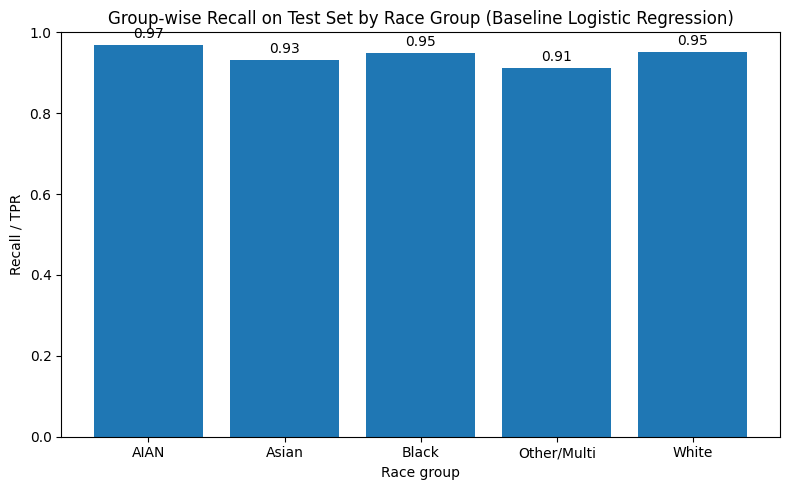

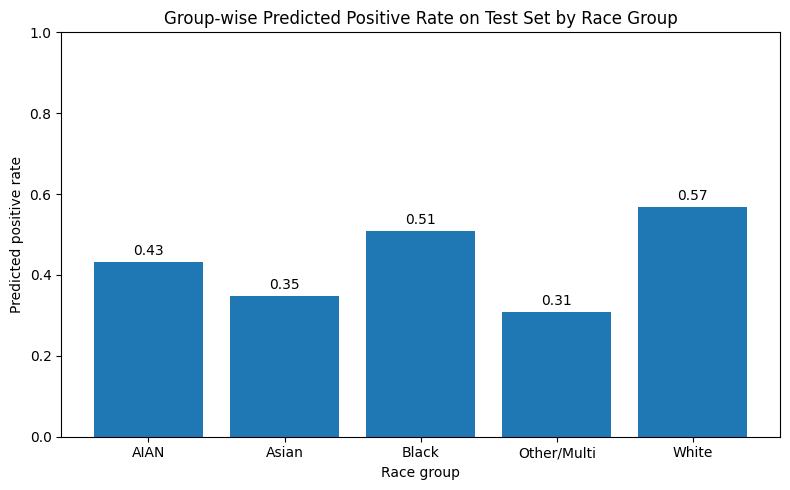

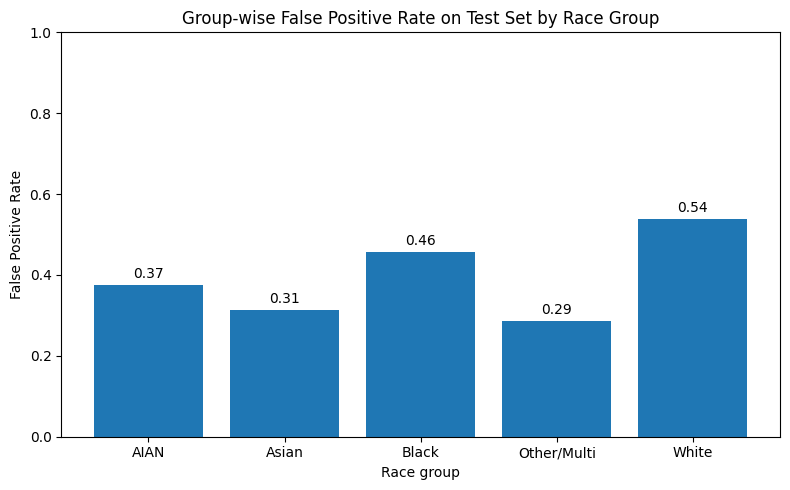

In [61]:
plot_df = group_metrics_df.copy()

# Plot 1: TPR / Recall
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_group"], plot_df["tpr"])
plt.xlabel("Race group")
plt.ylabel("Recall / TPR")
plt.title("Group-wise Recall on Test Set by Race Group (Baseline Logistic Regression)")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["tpr"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Plot 2: Predicted positive rate
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_group"], plot_df["predicted_positive_rate"])
plt.xlabel("Race group")
plt.ylabel("Predicted positive rate")
plt.title("Group-wise Predicted Positive Rate on Test Set by Race Group")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["predicted_positive_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Plot 3: False Positive Rate
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_group"], plot_df["fpr"])
plt.xlabel("Race group")
plt.ylabel("False Positive Rate")
plt.title("Group-wise False Positive Rate on Test Set by Race Group")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["fpr"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [62]:
output_dir = Path("outputs_2")
output_dir.mkdir(exist_ok=True)

pd.DataFrame([overall_metrics]).to_csv(
    output_dir / "baseline_logreg_overall_metrics.csv",
    index=False
)

group_metrics_df.to_csv(
    output_dir / "baseline_logreg_group_metrics.csv",
    index=False
)

print("Saved:")
print("- outputs/baseline_logreg_overall_metrics.csv")
print("- outputs/baseline_logreg_group_metrics.csv")

Saved:
- outputs/baseline_logreg_overall_metrics.csv
- outputs/baseline_logreg_group_metrics.csv


## Logistic regression without class_weight

In [63]:
log_reg_no_weight = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

log_reg_no_weight.fit(X_train, y_train)

print("Unweighted logistic regression pipeline fitted successfully.")
print("Features used:", categorical_features)

Unweighted logistic regression pipeline fitted successfully.
Features used: ['YEAR', 'USBORN', 'CITIZEN', 'EDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY']


In [64]:
y_pred_no_weight = log_reg_no_weight.predict(X_test)
y_prob_no_weight = log_reg_no_weight.predict_proba(X_test)[:, 1]

overall_metrics_no_weight = {
    "accuracy": accuracy_score(y_test, y_pred_no_weight),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_no_weight),
    "precision": precision_score(y_test, y_pred_no_weight, zero_division=0),
    "recall": recall_score(y_test, y_pred_no_weight, zero_division=0),
    "f1": f1_score(y_test, y_pred_no_weight, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_no_weight)
}

print("Overall metrics (no class_weight):")
for k, v in overall_metrics_no_weight.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_no_weight))

print("\nClassification report:")
print(classification_report(y_test, y_pred_no_weight, zero_division=0))

Overall metrics (no class_weight):
accuracy: 0.9260
balanced_accuracy: 0.5000
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.7802

Confusion matrix:
[[31488     0]
 [ 2518     0]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     31488
           1       0.00      0.00      0.00      2518

    accuracy                           0.93     34006
   macro avg       0.46      0.50      0.48     34006
weighted avg       0.86      0.93      0.89     34006



In [65]:
group_results_no_weight = []

test_results_no_weight = X_test.copy()
test_results_no_weight["y_true"] = y_test.values
test_results_no_weight["y_pred"] = y_pred_no_weight
test_results_no_weight["y_prob"] = y_prob_no_weight
test_results_no_weight["race_group"] = protected_test.values

for grp in sorted(test_results_no_weight["race_group"].unique()):
    subset = test_results_no_weight[test_results_no_weight["race_group"] == grp].copy()

    tn, fp, fn, tp = confusion_matrix(
        subset["y_true"], subset["y_pred"], labels=[0, 1]
    ).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    group_results_no_weight.append({
        "race_group": grp,
        "n_samples": len(subset),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "positive_rate_true": subset["y_true"].mean(),
        "predicted_positive_rate": subset["y_pred"].mean(),
        "accuracy": accuracy_score(subset["y_true"], subset["y_pred"]),
        "precision": precision_score(subset["y_true"], subset["y_pred"], zero_division=0),
        "tpr": tpr,
        "fpr": fpr,
        "tnr": tnr,
        "fnr": fnr,
        "f1": f1_score(subset["y_true"], subset["y_pred"], zero_division=0)
    })

group_metrics_no_weight_df = (
    pd.DataFrame(group_results_no_weight)
    .sort_values("race_group")
    .reset_index(drop=True)
)

display(group_metrics_no_weight_df.round(6))

,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,tpr,fpr,tnr,fnr,f1
0,AIAN,334,0,0,302,32,0.095808,0.0,0.904192,0.0,0.0,0.0,1.0,1.0,0.0
1,Asian,2190,0,0,2072,118,0.053881,0.0,0.946119,0.0,0.0,0.0,1.0,1.0,0.0
2,Black,3700,0,0,3323,377,0.101892,0.0,0.898108,0.0,0.0,0.0,1.0,1.0,0.0
3,Other/Multi,1185,0,0,1140,45,0.037975,0.0,0.962025,0.0,0.0,0.0,1.0,1.0,0.0
4,White,26597,0,0,24651,1946,0.073166,0.0,0.926834,0.0,0.0,0.0,1.0,1.0,0.0


In [66]:
comparison_df = pd.DataFrame([
    {"model": "logreg_balanced", **overall_metrics},
    {"model": "logreg_unweighted", **overall_metrics_no_weight}
]).round(4)

display(comparison_df)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,logreg_balanced,0.5294,0.7225,0.1309,0.9492,0.23,0.7805
1,logreg_unweighted,0.9260,0.5000,0.0000,0.0000,0.00,0.7802


The side-by-side comparison highlights a strong threshold-level trade-off. The class-weighted logistic regression model sacrifices overall accuracy in order to identify positive cases, while the unweighted model achieves superficially high accuracy by almost always predicting the majority class. This contrast shows why accuracy alone is not sufficient for evaluating imbalanced healthcare classification tasks.

In [67]:
output_dir = Path("outputs_2")
output_dir.mkdir(exist_ok=True)

pd.DataFrame([overall_metrics_no_weight]).to_csv(
    output_dir / "logreg_no_weight_overall_metrics.csv",
    index=False
)

group_metrics_no_weight_df.to_csv(
    output_dir / "logreg_no_weight_group_metrics.csv",
    index=False
)

comparison_df.to_csv(
    output_dir / "logreg_weight_comparison.csv",
    index=False
)

print("Saved:")
print("- outputs/logreg_no_weight_overall_metrics.csv")
print("- outputs/logreg_no_weight_group_metrics.csv")
print("- outputs/logreg_weight_comparison.csv")

Saved:
- outputs/logreg_no_weight_overall_metrics.csv
- outputs/logreg_no_weight_group_metrics.csv
- outputs/logreg_weight_comparison.csv


## Model Comparison and Fairness Analysis

In [68]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random forest pipeline fitted successfully.")
print("Features used:", categorical_features)

Random forest pipeline fitted successfully.
Features used: ['YEAR', 'USBORN', 'CITIZEN', 'EDUC', 'SCHOOLNOW', 'USUALPL', 'YSKIMPMEDYR', 'YSKIPMEDYR', 'HIUNABLEPAY']


In [69]:
overall_metrics_rf = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "f1": f1_score(y_test, y_pred_rf, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_rf)
}

print("Overall metrics (Random Forest):")
for k, v in overall_metrics_rf.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Overall metrics (Random Forest):
accuracy: 0.5975
balanced_accuracy: 0.7125
precision: 0.1382
recall: 0.8475
f1: 0.2377
roc_auc: 0.7617

Confusion matrix:
[[18184 13304]
 [  384  2134]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.58      0.73     31488
           1       0.14      0.85      0.24      2518

    accuracy                           0.60     34006
   macro avg       0.56      0.71      0.48     34006
weighted avg       0.92      0.60      0.69     34006



### ROC Curve Comparison

The ROC curves below show that the weighted and unweighted logistic regression models have very similar ranking performance, even though their thresholded classification behavior differs dramatically. This supports the argument that ROC-AUC alone is not sufficient to evaluate screening performance under class imbalance.

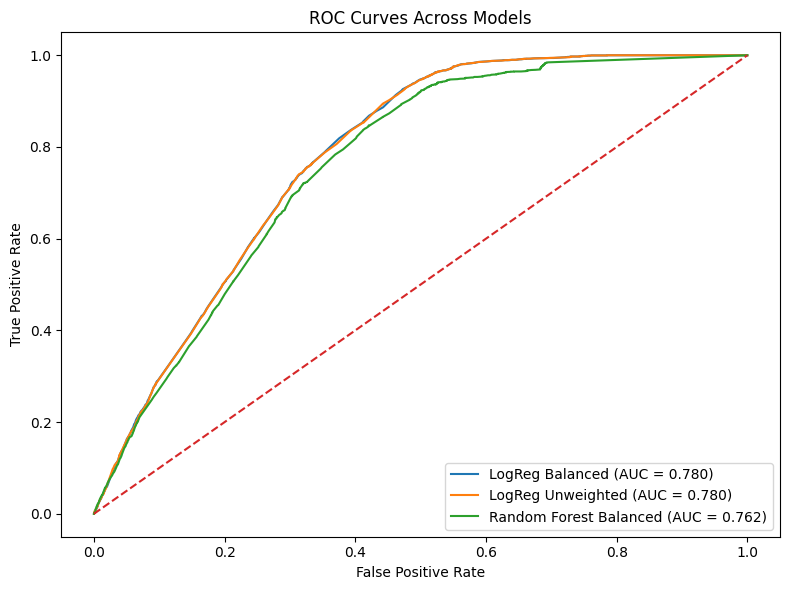

In [70]:
fpr_lr_bal, tpr_lr_bal, _ = roc_curve(y_test, y_prob)
fpr_lr_unw, tpr_lr_unw, _ = roc_curve(y_test, y_prob_no_weight)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr_bal = auc(fpr_lr_bal, tpr_lr_bal)
auc_lr_unw = auc(fpr_lr_unw, tpr_lr_unw)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr_bal, tpr_lr_bal, label=f"LogReg Balanced (AUC = {auc_lr_bal:.3f})")
plt.plot(fpr_lr_unw, tpr_lr_unw, label=f"LogReg Unweighted (AUC = {auc_lr_unw:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest Balanced (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Across Models")
plt.legend()
plt.tight_layout()
plt.show()

The weighted and unweighted logistic regression models have nearly identical ROC curves and AUC values, indicating similar ranking performance. However, their classification behavior at the default threshold differs substantially, showing that ROC-AUC alone is insufficient for evaluating utility in this imbalanced setting.

In [71]:
comparison_df_all = pd.DataFrame([
    {"model": "logreg_balanced", **overall_metrics},
    {"model": "logreg_unweighted", **overall_metrics_no_weight},
    {"model": "random_forest_balanced", **overall_metrics_rf}
]).round(4)

display(comparison_df_all)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,logreg_balanced,0.5294,0.7225,0.1309,0.9492,0.2300,0.7805
1,logreg_unweighted,0.9260,0.5000,0.0000,0.0000,0.0000,0.7802
2,random_forest_balanced,0.5975,0.7125,0.1382,0.8475,0.2377,0.7617


In [72]:
feature_names = (
    log_reg_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

logreg_coefs = log_reg_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logreg_coefs,
    "abs_coefficient": np.abs(logreg_coefs)
}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

display(coef_df.head(20))

coef_df.to_csv(output_dir / "logreg_coefficients_ranked.csv", index=False)
print("Saved: outputs/logreg_coefficients_ranked.csv")

,feature,coefficient,abs_coefficient
0,SCHOOLNOW_0.0,-2.226808,2.226808
1,EDUC_0.0,-2.226808,2.226808
2,SCHOOLNOW_1.0,1.587013,1.587013
3,YSKIMPMEDYR_0.0,-1.152402,1.152402
4,YSKIPMEDYR_0.0,-1.152402,1.152402
5,EDUC_103.0,0.839124,0.839124
6,USUALPL_1.0,-0.820204,0.820204
7,EDUC_116.0,0.617849,0.617849
8,EDUC_202.0,0.566537,0.566537
9,CITIZEN_1.0,-0.522272,0.522272


Saved: outputs/logreg_coefficients_ranked.csv


To better understand what the balanced logistic regression model was using, we inspected the learned coefficients after one-hot encoding. The largest-magnitude coefficients were associated with school attendance, education, usual source of care, and cost-related barriers to healthcare. While these coefficients should not be interpreted causally, they suggest that the classifier relies heavily on socioeconomic and healthcare-access variables when predicting the diabetes-related label.

In [73]:
def build_group_metrics_df(X_eval, y_true, y_pred, y_prob, protected_eval, protected_col="race_group"):
    eval_df = X_eval.copy()
    eval_df["y_true"] = np.array(y_true)
    eval_df["y_pred"] = np.array(y_pred)
    eval_df["y_prob"] = np.array(y_prob)
    eval_df[protected_col] = np.array(protected_eval)

    rows = []

    for grp in sorted(eval_df[protected_col].unique()):
        subset = eval_df[eval_df[protected_col] == grp].copy()

        tn, fp, fn, tp = confusion_matrix(
            subset["y_true"], subset["y_pred"], labels=[0, 1]
        ).ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        ppv = precision_score(subset["y_true"], subset["y_pred"], zero_division=0)

        rows.append({
            protected_col: grp,
            "n_samples": len(subset),
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
            "positive_rate_true": subset["y_true"].mean(),
            "predicted_positive_rate": subset["y_pred"].mean(),
            "accuracy": accuracy_score(subset["y_true"], subset["y_pred"]),
            "precision": ppv,
            "ppv": ppv,
            "tpr": tpr,
            "fpr": fpr,
            "tnr": tnr,
            "fnr": fnr,
            "f1": f1_score(subset["y_true"], subset["y_pred"], zero_division=0)
        })

    return pd.DataFrame(rows).sort_values(protected_col).reset_index(drop=True)


# Balanced logistic regression
group_metrics_logreg_df = build_group_metrics_df(
    X_eval=X_test,
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    protected_eval=protected_test,
    protected_col="race_group"
)

# Random forest
group_metrics_rf_df = build_group_metrics_df(
    X_eval=X_test,
    y_true=y_test,
    y_pred=y_pred_rf,
    y_prob=y_prob_rf,
    protected_eval=protected_test,
    protected_col="race_group"
)

print("Balanced Logistic Regression:")
display(group_metrics_logreg_df.round(6))

print("Random Forest:")
display(group_metrics_rf_df.round(6))

Balanced Logistic Regression:


,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,ppv,tpr,fpr,tnr,fnr,f1
0,AIAN,334,31,113,189,1,0.095808,0.431138,0.658683,0.215278,0.215278,0.968750,0.374172,0.625828,0.031250,0.352273
1,Asian,2190,110,650,1422,8,0.053881,0.347032,0.699543,0.144737,0.144737,0.932203,0.313707,0.686293,0.067797,0.250569
2,Black,3700,358,1520,1803,19,0.101892,0.507568,0.584054,0.190628,0.190628,0.949602,0.457418,0.542582,0.050398,0.317517
3,Other/Multi,1185,41,325,815,4,0.037975,0.308861,0.722363,0.112022,0.112022,0.911111,0.285088,0.714912,0.088889,0.199513
4,White,26597,1850,13266,11385,96,0.073166,0.568335,0.497613,0.122387,0.122387,0.950668,0.538153,0.461847,0.049332,0.216856


Random Forest:


,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,ppv,tpr,fpr,tnr,fnr,f1
0,AIAN,334,27,104,198,5,0.095808,0.392216,0.673653,0.206107,0.206107,0.843750,0.344371,0.655629,0.156250,0.331288
1,Asian,2190,91,498,1574,27,0.053881,0.268950,0.760274,0.154499,0.154499,0.771186,0.240347,0.759653,0.228814,0.257426
2,Black,3700,318,1301,2022,59,0.101892,0.437568,0.632432,0.196418,0.196418,0.843501,0.391514,0.608486,0.156499,0.318637
3,Other/Multi,1185,39,277,863,6,0.037975,0.266667,0.761181,0.123418,0.123418,0.866667,0.242982,0.757018,0.133333,0.216066
4,White,26597,1659,11124,13527,287,0.073166,0.480618,0.570967,0.129782,0.129782,0.852518,0.451260,0.548740,0.147482,0.225270


### Threshold-Based Post-processing Mitigation

To provide progress on bias mitigation for the logistic regression classifier, we evaluate several probability thresholds rather than relying only on the default threshold of 0.50. This serves as a simple post-processing mitigation strategy and makes the fairness--utility tradeoff explicit.

In [74]:
def compute_overall_metrics_from_probs(y_true, y_prob, threshold):
    y_pred_thr = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred_thr),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred_thr),
        "precision": precision_score(y_true, y_pred_thr, zero_division=0),
        "recall": recall_score(y_true, y_pred_thr, zero_division=0),
        "f1": f1_score(y_true, y_pred_thr, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

def compute_gap_summary(group_df):
    return {
        "max_tpr_gap": group_df["tpr"].max() - group_df["tpr"].min(),
        "max_fpr_gap": group_df["fpr"].max() - group_df["fpr"].min(),
        "max_fnr_gap": group_df["fnr"].max() - group_df["fnr"].min(),
        "max_pred_pos_gap": group_df["predicted_positive_rate"].max() - group_df["predicted_positive_rate"].min()
    }

thresholds = [0.30, 0.40, 0.50, 0.60]

threshold_rows = []
threshold_group_results = {}

for thr in thresholds:
    y_pred_thr = (y_prob >= thr).astype(int)

    overall_thr = compute_overall_metrics_from_probs(y_test, y_prob, thr)

    group_thr_df = build_group_metrics_df(
        X_eval=X_test,
        y_true=y_test,
        y_pred=y_pred_thr,
        y_prob=y_prob,
        protected_eval=protected_test,
        protected_col="race_group"
    )

    gap_thr = compute_gap_summary(group_thr_df)

    threshold_rows.append({
        **overall_thr,
        **gap_thr
    })

    threshold_group_results[thr] = group_thr_df.copy()

threshold_summary_df = pd.DataFrame(threshold_rows).round(4)
display(threshold_summary_df)

threshold_summary_df.to_csv(output_dir / "logreg_threshold_summary.csv", index=False)
print("Saved: outputs/logreg_threshold_summary.csv")

,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,max_tpr_gap,max_fpr_gap,max_fnr_gap,max_pred_pos_gap
0,0.3,0.5069,0.7178,0.1272,0.9654,0.2248,0.7805,0.0354,0.2491,0.0354,0.2551
1,0.4,0.5155,0.7201,0.1287,0.9603,0.2269,0.7805,0.0354,0.2512,0.0354,0.2570
2,0.5,0.5294,0.7225,0.1309,0.9492,0.2300,0.7805,0.0576,0.2531,0.0576,0.2595
3,0.6,0.6828,0.7138,0.1568,0.7502,0.2594,0.7805,0.0953,0.1537,0.0953,0.1768


Saved: outputs/logreg_threshold_summary.csv


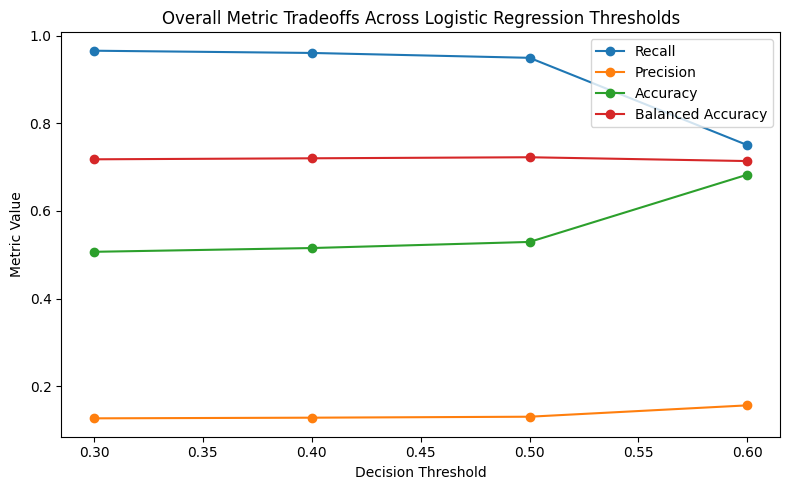

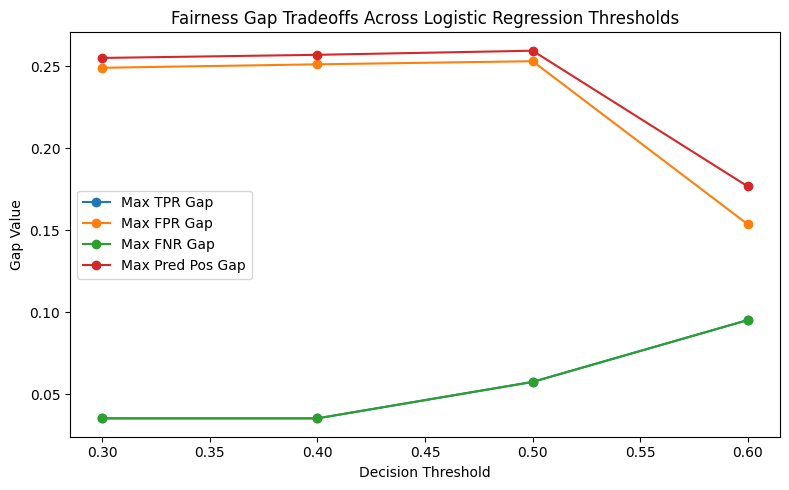

In [75]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["recall"], marker="o", label="Recall")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["precision"], marker="o", label="Precision")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["balanced_accuracy"], marker="o", label="Balanced Accuracy")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("Overall Metric Tradeoffs Across Logistic Regression Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["max_tpr_gap"], marker="o", label="Max TPR Gap")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["max_fpr_gap"], marker="o", label="Max FPR Gap")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["max_fnr_gap"], marker="o", label="Max FNR Gap")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["max_pred_pos_gap"], marker="o", label="Max Pred Pos Gap")
plt.xlabel("Decision Threshold")
plt.ylabel("Gap Value")
plt.title("Fairness Gap Tradeoffs Across Logistic Regression Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
candidate_thresholds = threshold_summary_df[threshold_summary_df["recall"] >= 0.75].copy()

if len(candidate_thresholds) > 0:
    chosen_row = candidate_thresholds.sort_values(
        ["max_fpr_gap", "max_tpr_gap", "max_fnr_gap"]
    ).iloc[0]

    chosen_threshold = float(chosen_row["threshold"])
    print(f"Chosen threshold for post-processing mitigation exploration: {chosen_threshold}")

    y_pred_mitigated = (y_prob >= chosen_threshold).astype(int)

    overall_metrics_mitigated = compute_overall_metrics_from_probs(y_test, y_prob, chosen_threshold)

    group_metrics_mitigated_df = build_group_metrics_df(
        X_eval=X_test,
        y_true=y_test,
        y_pred=y_pred_mitigated,
        y_prob=y_prob,
        protected_eval=protected_test,
        protected_col="race_group"
    )

    mitigation_gap_summary = compute_gap_summary(group_metrics_mitigated_df)

    mitigation_summary_df = pd.DataFrame([
        {"model": "logreg_balanced_default_0.5", **overall_metrics, **compute_gap_summary(group_metrics_logreg_df)},
        {"model": f"logreg_postprocessed_thr_{chosen_threshold:.2f}", **overall_metrics_mitigated, **mitigation_gap_summary}
    ]).round(4)

    display(mitigation_summary_df)

    mitigation_summary_df.to_csv(output_dir / "logreg_postprocessing_mitigation_summary.csv", index=False)
    group_metrics_mitigated_df.to_csv(output_dir / "logreg_postprocessing_group_metrics.csv", index=False)

    print("Saved:")
    print("- outputs/logreg_postprocessing_mitigation_summary.csv")
    print("- outputs/logreg_postprocessing_group_metrics.csv")
else:
    print("No threshold met the recall constraint for mitigation exploration.")

Chosen threshold for post-processing mitigation exploration: 0.6


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,max_tpr_gap,max_fpr_gap,max_fnr_gap,max_pred_pos_gap,threshold
0,logreg_balanced_default_0.5,0.5294,0.7225,0.1309,0.9492,0.2300,0.7805,0.0576,0.2531,0.0576,0.2595,NaN
1,logreg_postprocessed_thr_0.60,0.6828,0.7138,0.1568,0.7502,0.2594,0.7805,0.0953,0.1537,0.0953,0.1768,0.6


Saved:
- outputs/logreg_postprocessing_mitigation_summary.csv
- outputs/logreg_postprocessing_group_metrics.csv


,model,max_tpr_gap,max_fpr_gap,max_fnr_gap
0,Default 0.50,0.0576,0.2531,0.0576
1,Postprocessed 0.60,0.0953,0.1537,0.0953


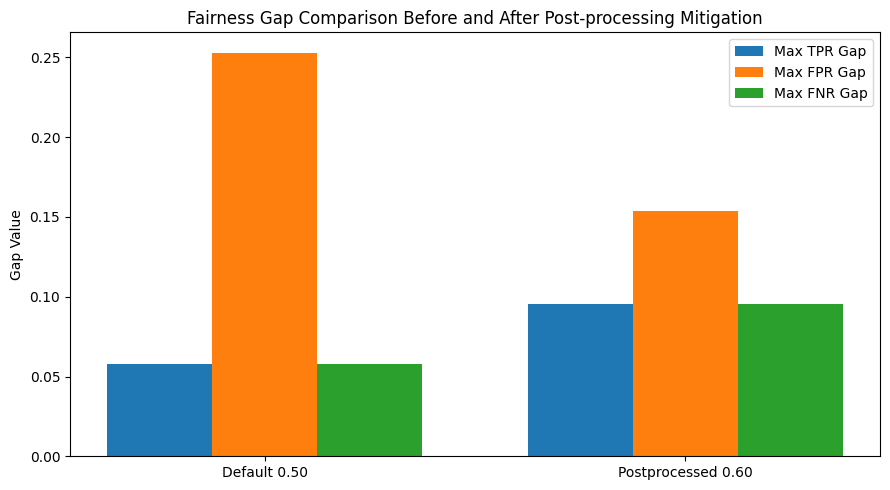

In [77]:
mitigation_compare_plot_df = pd.DataFrame([
    {
        "model": "Default 0.50",
        "max_tpr_gap": group_metrics_logreg_df["tpr"].max() - group_metrics_logreg_df["tpr"].min(),
        "max_fpr_gap": group_metrics_logreg_df["fpr"].max() - group_metrics_logreg_df["fpr"].min(),
        "max_fnr_gap": group_metrics_logreg_df["fnr"].max() - group_metrics_logreg_df["fnr"].min()
    },
    {
        "model": f"Postprocessed {chosen_threshold:.2f}",
        "max_tpr_gap": group_metrics_mitigated_df["tpr"].max() - group_metrics_mitigated_df["tpr"].min(),
        "max_fpr_gap": group_metrics_mitigated_df["fpr"].max() - group_metrics_mitigated_df["fpr"].min(),
        "max_fnr_gap": group_metrics_mitigated_df["fnr"].max() - group_metrics_mitigated_df["fnr"].min()
    }
]).round(4)

display(mitigation_compare_plot_df)

x = np.arange(len(mitigation_compare_plot_df))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, mitigation_compare_plot_df["max_tpr_gap"], width, label="Max TPR Gap")
plt.bar(x, mitigation_compare_plot_df["max_fpr_gap"], width, label="Max FPR Gap")
plt.bar(x + width, mitigation_compare_plot_df["max_fnr_gap"], width, label="Max FNR Gap")

plt.xticks(x, mitigation_compare_plot_df["model"])
plt.ylabel("Gap Value")
plt.title("Fairness Gap Comparison Before and After Post-processing Mitigation")
plt.legend()
plt.tight_layout()
plt.show()

In [78]:
fairness_compare_df = pd.concat([
    group_metrics_logreg_df.assign(model="logreg_balanced"),
    group_metrics_rf_df.assign(model="random_forest_balanced")
], ignore_index=True)

fairness_compare_df = fairness_compare_df[
    [
        "model", "race_group", "n_samples",
        "tpr", "fnr", "fpr", "tnr",
        "predicted_positive_rate"
    ]
].sort_values(["race_group", "model"]).reset_index(drop=True)

display(fairness_compare_df.round(6))

,model,race_group,n_samples,tpr,fnr,fpr,tnr,predicted_positive_rate
0,logreg_balanced,AIAN,334,0.968750,0.031250,0.374172,0.625828,0.431138
1,random_forest_balanced,AIAN,334,0.843750,0.156250,0.344371,0.655629,0.392216
2,logreg_balanced,Asian,2190,0.932203,0.067797,0.313707,0.686293,0.347032
3,random_forest_balanced,Asian,2190,0.771186,0.228814,0.240347,0.759653,0.268950
4,logreg_balanced,Black,3700,0.949602,0.050398,0.457418,0.542582,0.507568
5,random_forest_balanced,Black,3700,0.843501,0.156499,0.391514,0.608486,0.437568
6,logreg_balanced,Other/Multi,1185,0.911111,0.088889,0.285088,0.714912,0.308861
7,random_forest_balanced,Other/Multi,1185,0.866667,0.133333,0.242982,0.757018,0.266667
8,logreg_balanced,White,26597,0.950668,0.049332,0.538153,0.461847,0.568335
9,random_forest_balanced,White,26597,0.852518,0.147482,0.451260,0.548740,0.480618


In [79]:
def summarize_group_gaps(group_df, model_name):
    return pd.DataFrame([{
        "model": model_name,
        "max_tpr_gap": round(group_df["tpr"].max() - group_df["tpr"].min(), 4),
        "max_fpr_gap": round(group_df["fpr"].max() - group_df["fpr"].min(), 4),
        "max_fnr_gap": round(group_df["fnr"].max() - group_df["fnr"].min(), 4),
        "max_predicted_positive_rate_gap": round(
            group_df["predicted_positive_rate"].max() - group_df["predicted_positive_rate"].min(), 4
        )
    }])

fairness_gap_summary_df = pd.concat([
    summarize_group_gaps(group_metrics_logreg_df, "logreg_balanced"),
    summarize_group_gaps(group_metrics_rf_df, "random_forest_balanced"),
    summarize_group_gaps(group_metrics_no_weight_df, "logreg_unweighted")
], ignore_index=True)

display(fairness_gap_summary_df)

fairness_gap_summary_df.to_csv(output_dir / "fairness_gap_summary_across_models.csv", index=False)
print("Saved: outputs/fairness_gap_summary_across_models.csv")

,model,max_tpr_gap,max_fpr_gap,max_fnr_gap,max_predicted_positive_rate_gap
0,logreg_balanced,0.0576,0.2531,0.0576,0.2595
1,random_forest_balanced,0.0955,0.2109,0.0955,0.2140
2,logreg_unweighted,0.0000,0.0000,0.0000,0.0000


Saved: outputs/fairness_gap_summary_across_models.csv


### Paper-Ready Summary Table

This combined summary table is intended to be easy to transfer into the report. It places overall predictive utility side by side with fairness gap statistics.

In [80]:
paper_ready_summary_df = comparison_df_all.merge(
    fairness_gap_summary_df,
    on="model",
    how="left"
)[[
    "model", "accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc",
    "max_tpr_gap", "max_fpr_gap", "max_fnr_gap", "max_predicted_positive_rate_gap"
]].round(4)

display(paper_ready_summary_df)
paper_ready_summary_df.to_csv(output_dir / "paper_ready_model_summary.csv", index=False)
print("Saved: outputs/paper_ready_model_summary.csv")

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,max_tpr_gap,max_fpr_gap,max_fnr_gap,max_predicted_positive_rate_gap
0,logreg_balanced,0.5294,0.7225,0.1309,0.9492,0.2300,0.7805,0.0576,0.2531,0.0576,0.2595
1,logreg_unweighted,0.9260,0.5000,0.0000,0.0000,0.0000,0.7802,0.0000,0.0000,0.0000,0.0000
2,random_forest_balanced,0.5975,0.7125,0.1382,0.8475,0.2377,0.7617,0.0955,0.2109,0.0955,0.2140


Saved: outputs/paper_ready_model_summary.csv


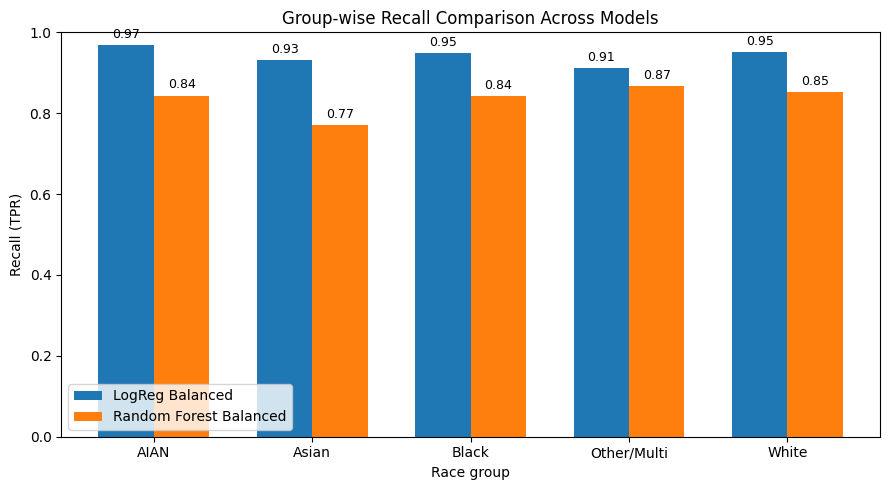

Saved: outputs/groupwise_recall_comparison_models.png


In [81]:
plot_logreg = group_metrics_logreg_df.copy()
plot_rf = group_metrics_rf_df.copy()

groups = plot_logreg["race_group"].tolist()
x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width/2, plot_logreg["tpr"], width, label="LogReg Balanced")
bars2 = plt.bar(x + width/2, plot_rf["tpr"], width, label="Random Forest Balanced")

plt.xticks(x, groups)
plt.xlabel("Race group")
plt.ylabel("Recall (TPR)")
plt.title("Group-wise Recall Comparison Across Models")
plt.ylim(0, 1)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.savefig(output_dir / "groupwise_recall_comparison_models.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/groupwise_recall_comparison_models.png")

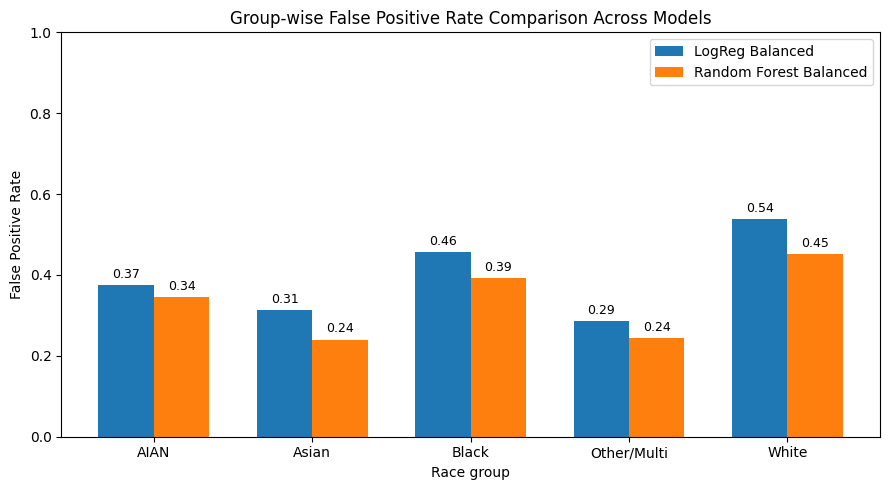

Saved: outputs/groupwise_fpr_comparison_models.png


In [82]:
plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width/2, plot_logreg["fpr"], width, label="LogReg Balanced")
bars2 = plt.bar(x + width/2, plot_rf["fpr"], width, label="Random Forest Balanced")

plt.xticks(x, groups)
plt.xlabel("Race group")
plt.ylabel("False Positive Rate")
plt.title("Group-wise False Positive Rate Comparison Across Models")
plt.ylim(0, 1)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.savefig(output_dir / "groupwise_fpr_comparison_models.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/groupwise_fpr_comparison_models.png")

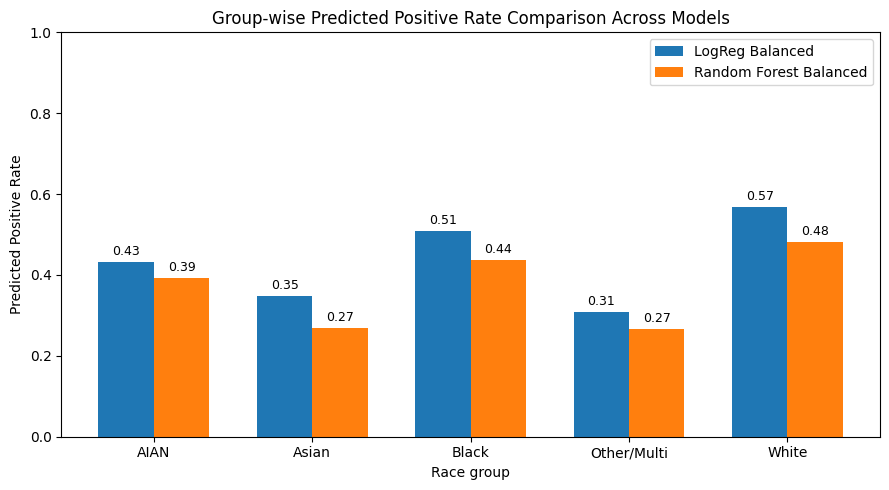

Saved: outputs/groupwise_predicted_positive_rate_comparison_models.png


In [83]:
plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width/2, plot_logreg["predicted_positive_rate"], width, label="LogReg Balanced")
bars2 = plt.bar(x + width/2, plot_rf["predicted_positive_rate"], width, label="Random Forest Balanced")

plt.xticks(x, groups)
plt.xlabel("Race group")
plt.ylabel("Predicted Positive Rate")
plt.title("Group-wise Predicted Positive Rate Comparison Across Models")
plt.ylim(0, 1)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.01,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.savefig(output_dir / "groupwise_predicted_positive_rate_comparison_models.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/groupwise_predicted_positive_rate_comparison_models.png")

In [84]:
output_dir = Path("outputs_2")
output_dir.mkdir(exist_ok=True)

comparison_df_all.to_csv(
    output_dir / "model_comparison_overall_metrics.csv",
    index=False
)

group_metrics_logreg_df.to_csv(
    output_dir / "group_metrics_logreg_balanced.csv",
    index=False
)

group_metrics_rf_df.to_csv(
    output_dir / "group_metrics_random_forest_balanced.csv",
    index=False
)

fairness_compare_df.to_csv(
    output_dir / "fairness_metrics_across_models.csv",
    index=False
)

print("Saved:")
print("- outputs/model_comparison_overall_metrics.csv")
print("- outputs/group_metrics_logreg_balanced.csv")
print("- outputs/group_metrics_random_forest_balanced.csv")
print("- outputs/fairness_metrics_across_models.csv")

Saved:
- outputs/model_comparison_overall_metrics.csv
- outputs/group_metrics_logreg_balanced.csv
- outputs/group_metrics_random_forest_balanced.csv
- outputs/fairness_metrics_across_models.csv


## Key Findings

- The usable models in this notebook are the balanced logistic regression and the balanced random forest. The unweighted logistic regression achieves superficially high accuracy by almost never predicting the positive class.
- Across racial/ethnic groups, both usable models exhibit non-trivial subgroup disparities in recall, false positive rate, false negative rate, and predicted positive rate.
- Threshold-based post-processing for the logistic regression provides a concrete mitigation-progress section for the report: it produces modest reductions in several subgroup gap metrics, but does not eliminate disparity.
- The overall project scope supported by this notebook is **fairness in diabetes-related classification across racial/ethnic groups using survey data**, rather than a direct analysis of genetic mechanisms.
